In [11]:
import kagglehub
import os
from pathlib import Path
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
_cache = Path.home() / ".cache" / "kagglehub" / "datasets" / "akashrayhan" / "yoga-82" / "versions"
if _cache.exists() and any(_cache.iterdir()):
    path = str(sorted(_cache.iterdir())[-1])
    print("Using cached dataset:", path)
else:
    path = kagglehub.dataset_download("akashrayhan/yoga-82")
    print("Downloaded dataset to:", path)

Using cached dataset: /Users/martinm/.cache/kagglehub/datasets/akashrayhan/yoga-82/versions/1


In [13]:
# Number of classes

def count_classes_and_samples(path: Path):
    samples = 0
    for entry in path.iterdir():
        if not entry.is_dir():
            continue
        class_samples = count_folders(entry)
        samples += class_samples
    classes = count_folders(path)
    return samples, classes

def count_folders(path):
    return sum(1 for _ in path.iterdir())

path = Path(path)

for set in ['train', 'test', 'valid']:    
    samples, classes = count_classes_and_samples(path / set)
    print(f'{set} size: {samples}, classes: {classes}')

train size: 11652, classes: 82
test size: 1764, classes: 82
valid size: 3351, classes: 82


In [14]:
# Image resolution stats

VALID_EXT = {".jpg", ".jpeg"}

def iter_images(split_path: Path):
    for class_dir in split_path.iterdir():
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in VALID_EXT:
                yield img_path


def get_image_size(img_path: Path):
    with Image.open(img_path) as img:
        return img.size  # (w, h)


def compute_split_stats(split_path: Path):
    widths, heights = [], []
    for img_path in iter_images(split_path):
        try:
            w, h = get_image_size(img_path)
            widths.append(w)
            heights.append(h)
        except Exception:
            continue
    if not widths:
        return None
    widths = np.array(widths)
    heights = np.array(heights)
    return {
        "count": len(widths),
        "min_width": int(widths.min()),
        "max_width": int(widths.max()),
        "avg_width": float(widths.mean()),
        "min_height": int(heights.min()),
        "max_height": int(heights.max()),
        "avg_height": float(heights.mean()),
    }

# ---- main ----

split_stats = {}

for split in ["train", "valid", "test"]:
    stats = compute_split_stats(path / split)
    split_stats[split] = stats

    print(f"\n=== {split.upper()} ===")
    if stats is None:
        print("No images found.")
        continue
    print(f"Images: {stats['count']}")
    print(f"Width : min={stats['min_width']}, max={stats['max_width']}, avg={stats['avg_width']:.1f}")
    print(f"Height: min={stats['min_height']}, max={stats['max_height']}, avg={stats['avg_height']:.1f}")

/Users/martinm/Documents/University/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))



=== TRAIN ===
Images: 11652
Width : min=1, max=6240, avg=744.3
Height: min=1, max=5244, avg=622.4

=== VALID ===
Images: 3351
Width : min=53, max=6016, avg=760.8
Height: min=49, max=5184, avg=633.4

=== TEST ===
Images: 1764
Width : min=1, max=6016, avg=776.8
Height: min=1, max=4000, avg=618.1


In [15]:
IMG_SIZE  = 384
RESIZE_TO = 440  # resize shorter side (~1.15x crop size), then crop

print("Average image resolutions in dataset:")
for split, stats in split_stats.items():
    if stats:
        print(f"  {split:5s}: {stats['avg_width']:.0f} x {stats['avg_height']:.0f} px")
print(f"\nTraining at: {IMG_SIZE}x{IMG_SIZE}  (shorter side resized to {RESIZE_TO} before crop)\n")

train_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(path / "train", transform=train_transform)
val_ds   = datasets.ImageFolder(path / "valid", transform=val_test_transform)
test_ds  = datasets.ImageFolder(path / "test",  transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_ds.classes)
print("Classes:", num_classes)

Average image resolutions in dataset:
  train: 744 x 622 px
  valid: 761 x 633 px
  test : 777 x 618 px

Training at: 384x384  (shorter side resized to 440 before crop)

Classes: 82


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device to be used: ", device)

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

Device to be used:  cpu


In [17]:
from collections import Counter

# Class-weighted loss to handle imbalance
class_counts = Counter(label for _, label in train_ds.samples)
class_weights = torch.tensor(
    [len(train_ds) / (num_classes * class_counts[i]) for i in range(num_classes)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

Figures will be saved to: /Users/martinm/Documents/University/2semestras/DL/Project/yoga-pose-classification/doc/img


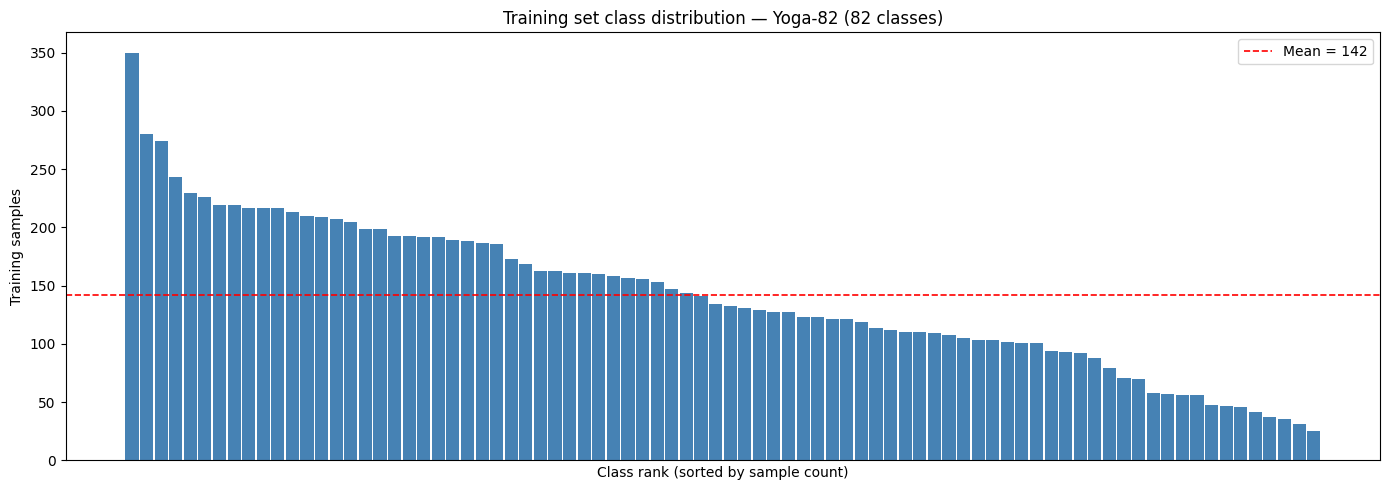

Saved fig_class_dist.png


In [18]:
# Set to True to skip training and load the saved best_model.pt checkpoint directly
SKIP_TRAINING = True

IMG_DIR = Path("../doc/img")
IMG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {IMG_DIR.resolve()}")

# --- Class distribution figure ---
import matplotlib.pyplot as plt

sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
class_names   = [train_ds.classes[c].replace("_", " ").strip() for c, _ in sorted_counts]
counts        = [n for _, n in sorted_counts]
mean_count    = sum(counts) / len(counts)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(counts)), counts, color="steelblue", width=0.9)
ax.axhline(mean_count, color="red", linestyle="--", linewidth=1.2, label=f"Mean = {mean_count:.0f}")
ax.set_xlabel("Class rank (sorted by sample count)")
ax.set_ylabel("Training samples")
ax.set_title("Training set class distribution — Yoga-82 (82 classes)")
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "fig_class_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_class_dist.png")

In [19]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            preds = out.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return correct / total, all_preds, all_labels

In [20]:
EPOCHS   = 15 if device == "cuda" else 5
PATIENCE = 3

epoch_history = []

if SKIP_TRAINING:
    # Results from the saved checkpoint run — used for the training curve figure
    epoch_history = [
        {"epoch":  1, "loss": 3.8105, "val_acc": 0.4587},
        {"epoch":  2, "loss": 2.2018, "val_acc": 0.6604},
        {"epoch":  3, "loss": 1.4898, "val_acc": 0.7359},
        {"epoch":  4, "loss": 1.1391, "val_acc": 0.7654},
        {"epoch":  5, "loss": 0.9323, "val_acc": 0.7911},
        {"epoch":  6, "loss": 0.7964, "val_acc": 0.8063},
        {"epoch":  7, "loss": 0.6855, "val_acc": 0.8236},
        {"epoch":  8, "loss": 0.6157, "val_acc": 0.8269},
        {"epoch":  9, "loss": 0.5580, "val_acc": 0.8350},
        {"epoch": 10, "loss": 0.5175, "val_acc": 0.8371},
        {"epoch": 11, "loss": 0.4859, "val_acc": 0.8392},
        {"epoch": 12, "loss": 0.4703, "val_acc": 0.8457},
        {"epoch": 13, "loss": 0.4500, "val_acc": 0.8445},
        {"epoch": 14, "loss": 0.4389, "val_acc": 0.8400},
        {"epoch": 15, "loss": 0.4296, "val_acc": 0.8415},
    ]
    print("Skipping training — loading checkpoint from best_model.pt")
else:
    best_val_acc     = 0.0
    patience_counter = 0

    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_loader)
        acc, _, _ = evaluate(model, val_loader)
        scheduler.step()

        lr = optimizer.param_groups[0]["lr"]
        epoch_history.append({"epoch": epoch + 1, "loss": loss, "val_acc": acc})
        print(f"Epoch {epoch+1:2d}: loss={loss:.4f}  val_acc={acc:.4f}  lr={lr:.2e}")

        if acc > best_val_acc:
            best_val_acc = acc
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1} (patience={PATIENCE}). Best val_acc: {best_val_acc:.4f}")
                break

model.load_state_dict(torch.load("best_model.pt", map_location=device, weights_only=False))
best_val_acc = max(e["val_acc"] for e in epoch_history)
print(f"\nLoaded best_model.pt  (best val_acc = {best_val_acc:.4f})")

Skipping training — loading checkpoint from best_model.pt

Loaded best_model.pt  (best val_acc = 0.8457)


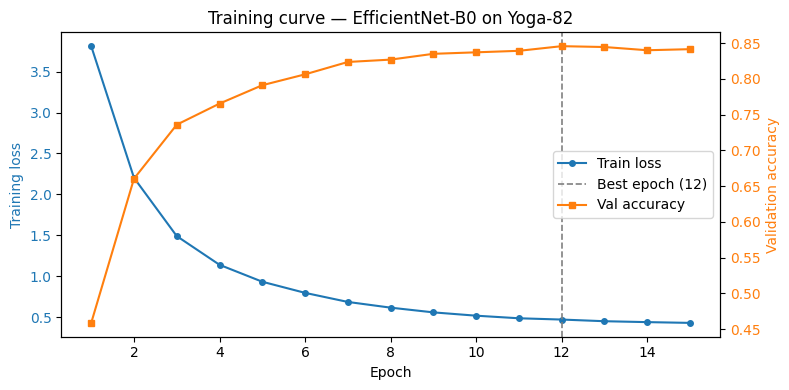

Saved fig_training_curve.png


In [21]:
import matplotlib.pyplot as plt

epochs   = [e["epoch"]   for e in epoch_history]
losses   = [e["loss"]    for e in epoch_history]
val_accs = [e["val_acc"] for e in epoch_history]
best_epoch = max(epoch_history, key=lambda e: e["val_acc"])["epoch"]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(epochs, losses,   color="tab:blue",   marker="o", markersize=4, label="Train loss")
ax2.plot(epochs, val_accs, color="tab:orange", marker="s", markersize=4, label="Val accuracy")
ax1.axvline(best_epoch, color="gray", linestyle="--", linewidth=1.2, label=f"Best epoch ({best_epoch})")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training loss", color="tab:blue")
ax2.set_ylabel("Validation accuracy", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.title("Training curve — EfficientNet-B0 on Yoga-82")
plt.tight_layout()
plt.savefig(IMG_DIR / "fig_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_training_curve.png")

In [22]:
acc, preds, labels = evaluate(model, test_loader)

print("Test accuracy:", acc)

print("\nClassification report:")
print(classification_report(labels, preds, target_names=test_ds.classes))

cm = confusion_matrix(labels, preds)
print("\nConfusion matrix shape:", cm.shape)

/Users/martinm/Documents/University/.venv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/Users/martinm/Documents/University/.venv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test accuracy: 0.8509070294784581

Classification report:
                                                                           precision    recall  f1-score   support

                                                       Akarna_Dhanurasana       0.82      1.00      0.90         9
                              Bharadvajas_Twist_pose_or_Bharadvajasana_I_       0.56      0.56      0.56         9
                                         Boat_Pose_or_Paripurna_Navasana_       0.88      0.90      0.89        31
                                     Bound_Angle_Pose_or_Baddha_Konasana_       0.77      0.92      0.84        26
                                                 Bow_Pose_or_Dhanurasana_       0.96      1.00      0.98        23
                                 Bridge_Pose_or_Setu_Bandha_Sarvangasana_       1.00      0.86      0.92        28
                                                 Camel_Pose_or_Ustrasana_       0.94      0.97      0.96        34
                     

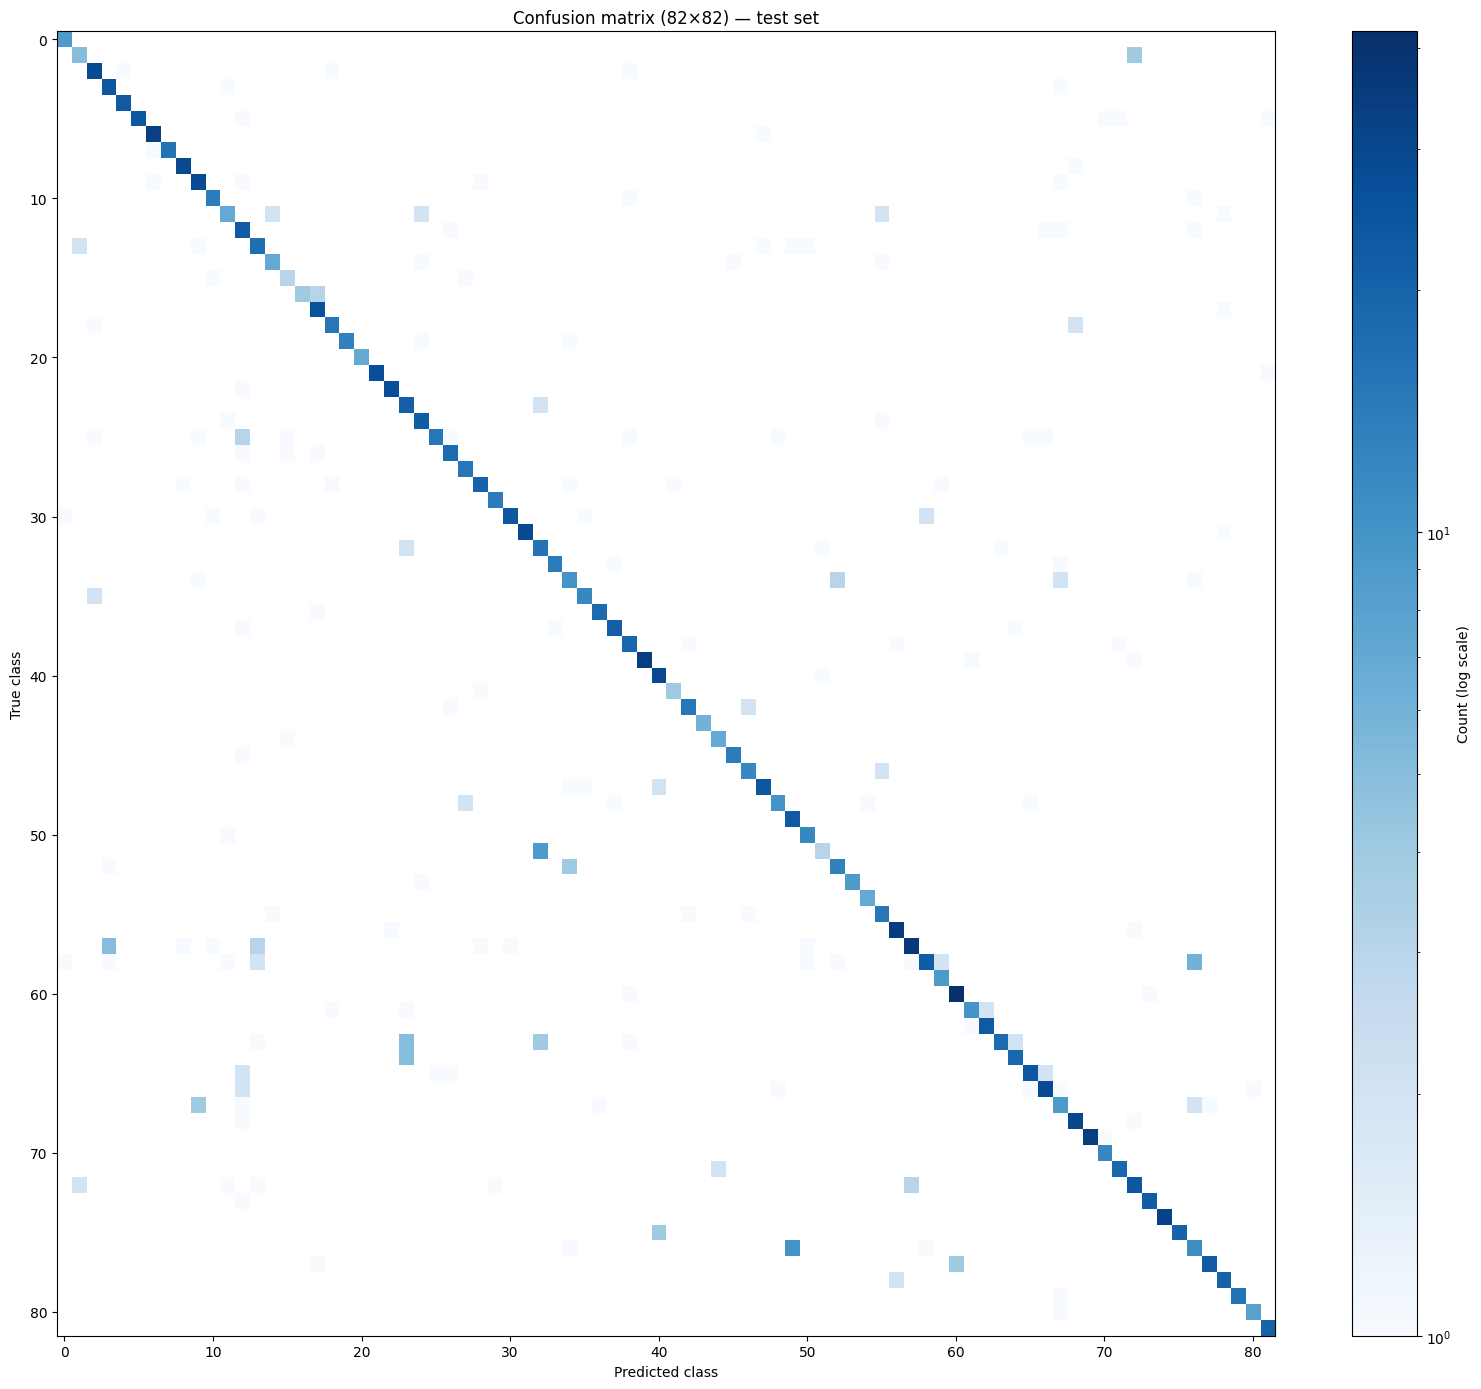

Saved fig_confusion_matrix.png


In [23]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

vmin = max(1, cm[cm > 0].min())
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, norm=LogNorm(vmin=vmin, vmax=cm.max()), cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Count (log scale)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Confusion matrix (82×82) — test set")
plt.tight_layout()
plt.savefig(IMG_DIR / "fig_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_confusion_matrix.png")

In [24]:
report = classification_report(labels, preds, target_names=test_ds.classes, output_dict=True)

weak_classes = sorted(
    [(k, v["f1-score"]) for k, v in report.items() if k in test_ds.classes],
    key=lambda x: x[1]
)

print("Worst classes:")
print(weak_classes[:10])

Worst classes:
[('Scorpion_pose_or_vrischikasana', 0.35294117647058826), ('Wide-Angle_Seated_Forward_Bend_pose_or_Upavistha_Konasana_', 0.4888888888888889), ('Tortoise_Pose', 0.5), ('Cockerel_Pose', 0.5384615384615384), ('Dolphin_Plank_Pose_or_Makara_Adho_Mukha_Svanasana_', 0.5454545454545454), ('Bharadvajas_Twist_pose_or_Bharadvajasana_I_', 0.5555555555555556), ('Head-to-Knee_Forward_Bend_pose_or_Janu_Sirsasana_', 0.5714285714285714), ('Handstand_pose_or_Adho_Mukha_Vrksasana_', 0.6274509803921569), ('Corpse_Pose_or_Savasana_', 0.6865671641791045), ('Split pose', 0.6984126984126984)]


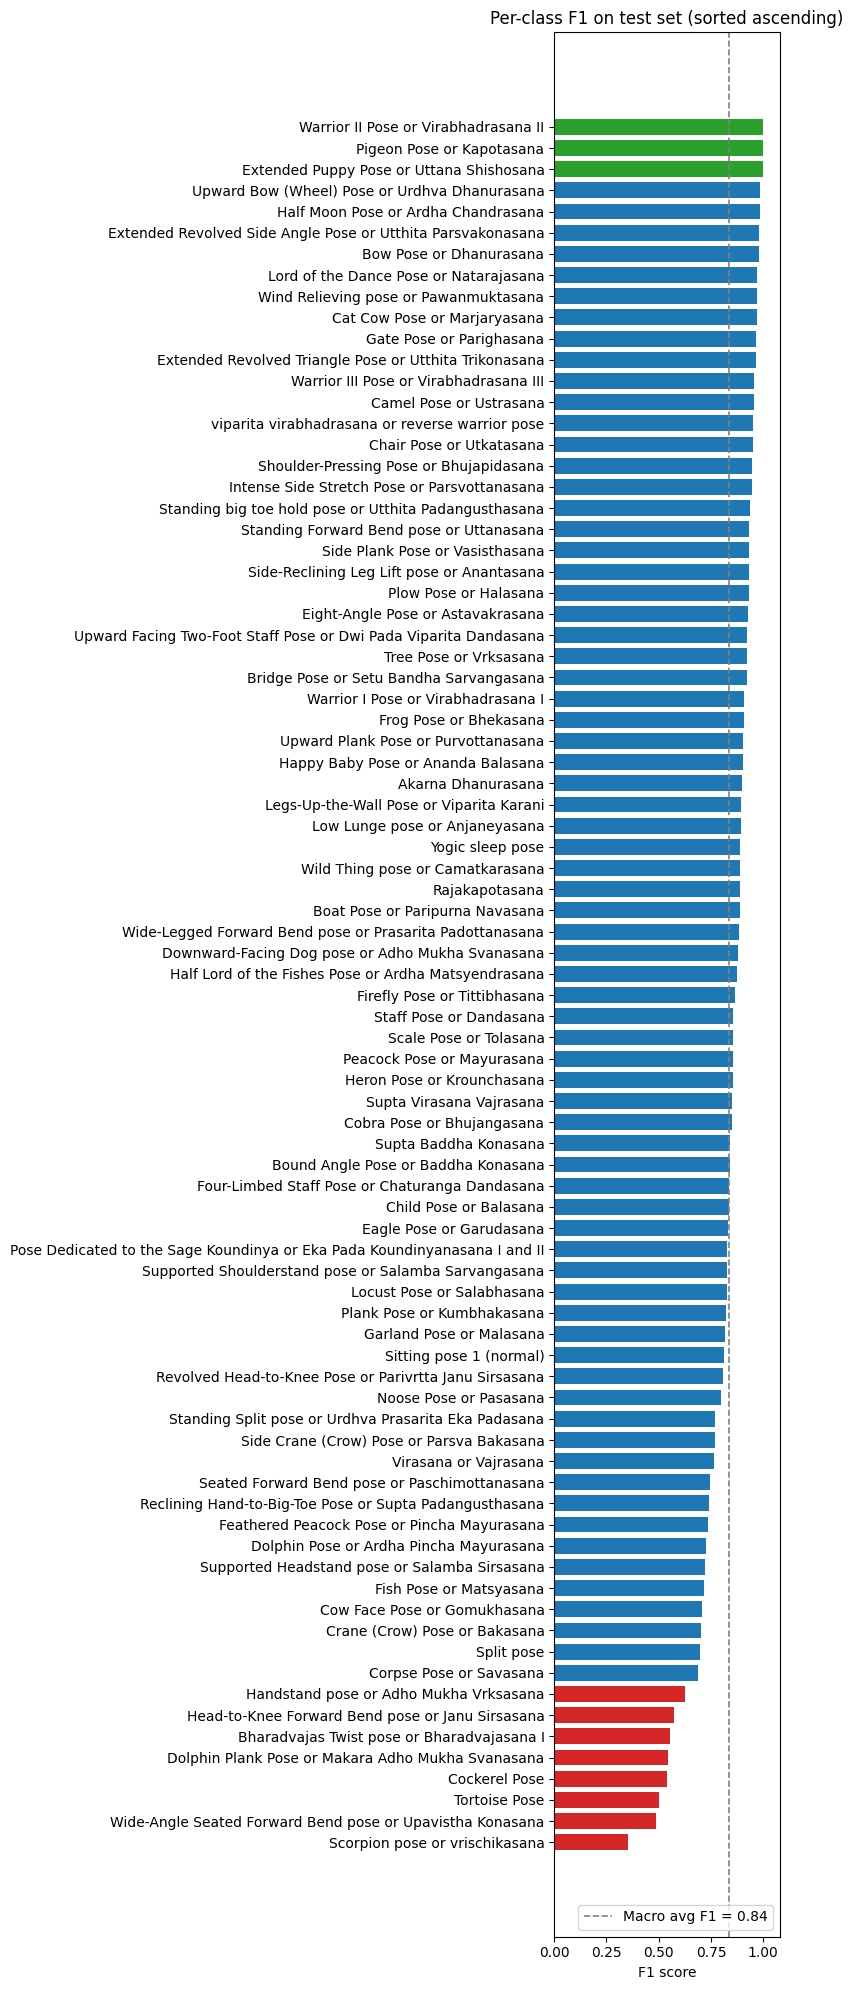

Saved fig_f1_per_class.png


In [25]:
import matplotlib.pyplot as plt

f1_items = [(k, v["f1-score"]) for k, v in report.items() if k in test_ds.classes]
f1_items.sort(key=lambda x: x[1])

names  = [x[0].replace("_", " ").strip() for x in f1_items]
scores = [x[1] for x in f1_items]
macro_f1 = sum(scores) / len(scores)
colors = ["#d62728" if s < 0.65 else ("#2ca02c" if s >= 1.0 else "#1f77b4") for s in scores]

fig, ax = plt.subplots(figsize=(8, 20))
ax.barh(names, scores, color=colors, height=0.75)
ax.set_xlim(0, 1.08)
ax.set_xlabel("F1 score")
ax.set_title("Per-class F1 on test set (sorted ascending)")
ax.axvline(macro_f1, color="gray", linestyle="--", linewidth=1.2, label=f"Macro avg F1 = {macro_f1:.2f}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(IMG_DIR / "fig_f1_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_f1_per_class.png")

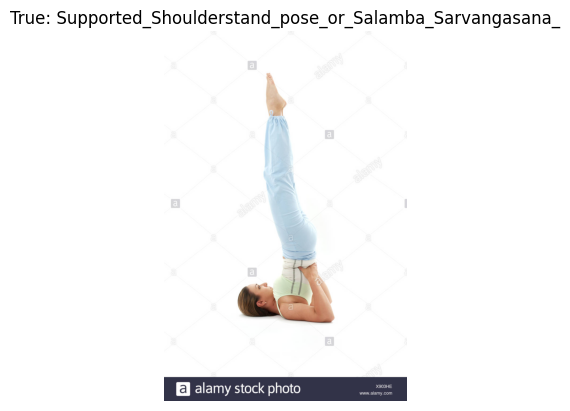

Predicted : Supported_Shoulderstand_pose_or_Salamba_Sarvangasana_ (98.2%)
True label: Supported_Shoulderstand_pose_or_Salamba_Sarvangasana_
Correct   : True


In [26]:
import random
import matplotlib.pyplot as plt

random.seed(42)

img_path, true_idx = random.choice(val_ds.samples)
true_label = val_ds.classes[true_idx]

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.title(f"True: {true_label}")
plt.axis("off")
plt.show()

img_tensor = val_test_transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    out = model(img_tensor)
    pred_idx = out.argmax(dim=1).item()
    confidence = torch.softmax(out, dim=1)[0, pred_idx].item()

pred_label = val_ds.classes[pred_idx]
print(f"Predicted : {pred_label} ({confidence:.1%})")
print(f"True label: {true_label}")
print(f"Correct   : {pred_label == true_label}")

In [27]:
import torch.nn.functional as F
from tqdm import tqdm

EMBEDDINGS_PATH = "train_embeddings.npz"

def extract_features(imgs):
    feats = model.features(imgs)
    feats = model.avgpool(feats)
    return torch.flatten(feats, 1)

if Path(EMBEDDINGS_PATH).exists():
    data = np.load(EMBEDDINGS_PATH)
    train_embeddings = torch.from_numpy(data["embeddings"])
    print(f"Loaded index from {EMBEDDINGS_PATH}  shape: {train_embeddings.shape}")
else:
    index_loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)

    train_embeddings = []
    model.eval()
    with torch.no_grad():
        for x, _ in tqdm(index_loader, desc="Indexing train set"):
            train_embeddings.append(extract_features(x.to(device)).cpu())

    train_embeddings = torch.cat(train_embeddings, dim=0)
    train_embeddings = F.normalize(train_embeddings, dim=1)

    np.savez(EMBEDDINGS_PATH, embeddings=train_embeddings.numpy())
    print(f"Saved index to {EMBEDDINGS_PATH}  shape: {train_embeddings.shape}")

Loaded index from train_embeddings.npz  shape: torch.Size([11652, 1280])


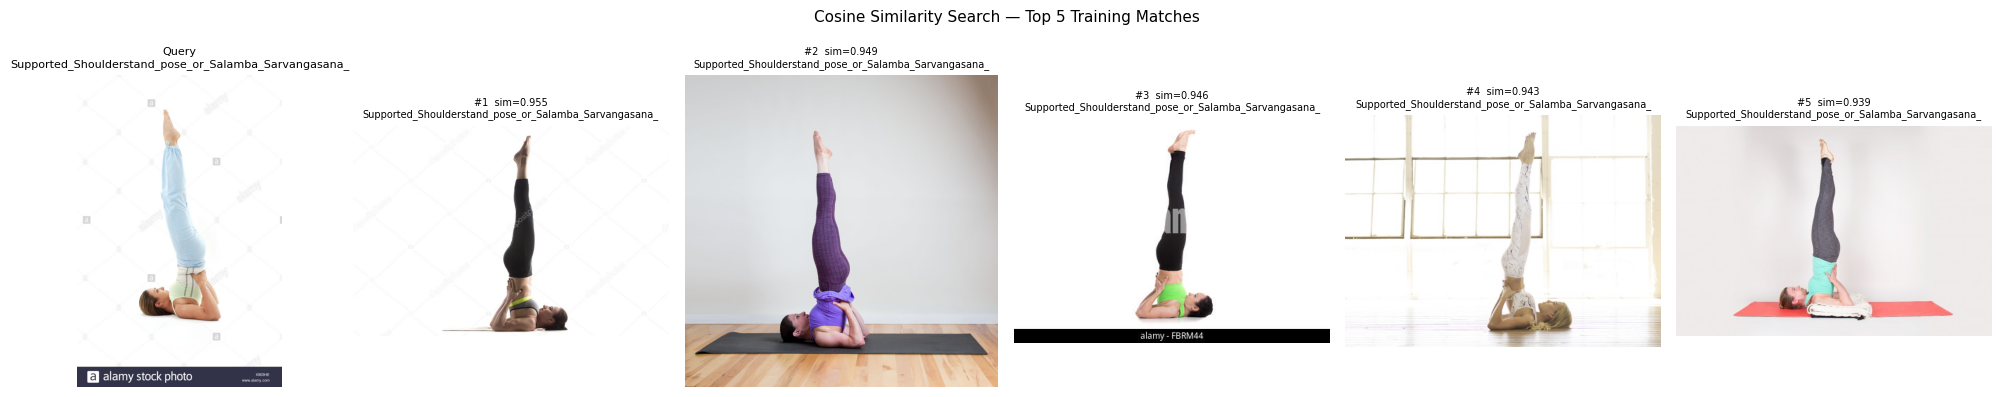

Saved fig_retrieval.png


In [28]:
with torch.no_grad():
    query_emb = F.normalize(extract_features(img_tensor.to(device)).cpu(), dim=1)

sims = (train_embeddings @ query_emb.T).squeeze()
top5 = sims.topk(5)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))

axes[0].imshow(img)
axes[0].set_title(f"Query\n{true_label}", fontsize=8)
axes[0].axis("off")

for i, (idx, score) in enumerate(zip(top5.indices, top5.values)):
    match_path, match_class_idx = train_ds.samples[idx.item()]
    match_label = train_ds.classes[match_class_idx]
    match_img = Image.open(match_path).convert("RGB")
    axes[i + 1].imshow(match_img)
    axes[i + 1].set_title(f"#{i+1}  sim={score:.3f}\n{match_label}", fontsize=7)
    axes[i + 1].axis("off")

plt.suptitle("Cosine Similarity Search — Top 5 Training Matches", fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / "fig_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_retrieval.png")